# Train CNN, ViT, and Hybrid Models on Devanagari Dataset

This notebook trains three models:
1. CNN (Convolutional Neural Network)
2. ViT (Vision Transformer)
3. Hybrid Model (CNN + ViT)

All models are trained for 1 epoch as specified.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import os
import sys

# Import tqdm with Jupyter notebook support
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm
    print("Note: Install tqdm for better progress bars: pip install tqdm")

# Check PyTorch and CUDA setup
print("=" * 60)
print("PyTorch Configuration Check")
print("=" * 60)
print(f"PyTorch Version: {torch.__version__}")

# Set device and check GPU availability
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"\n✅ CUDA is available!")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU Memory: {gpu_props.total_memory / 1024**3:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    # Clear any existing cache
    torch.cuda.empty_cache()
    print(f"\n🚀 Ready for GPU training on {torch.cuda.get_device_name(0)}!")
else:
    device = torch.device('cpu')
    print(f"\n⚠️ CUDA is not available. Using CPU (training will be slower).")
    print("\nTo enable GPU training on your GTX 1650:")
    print("1. Make sure you have NVIDIA drivers installed")
    print("2. Install PyTorch with CUDA support:")
    print("   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118")
    print("   (or cu121 for CUDA 12.1)")

print(f"\nUsing device: {device}")
print("=" * 60)

# Set paths
DATA_DIR = Path('../data/devanagari')
TRAIN_DIR = DATA_DIR / 'Train'
TEST_DIR = DATA_DIR / 'Test'
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# Load class mappings
with open('../utils/class_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)
    class_to_idx = mappings['class_to_idx']
    idx_to_class = mappings['idx_to_class']
    classes = mappings['classes']

num_classes = len(classes)
print(f"Number of classes: {num_classes}")


PyTorch Configuration Check
PyTorch Version: 2.9.1+cpu

⚠️ CUDA is not available. Using CPU (training will be slower).

To enable GPU training on your GTX 1650:
1. Make sure you have NVIDIA drivers installed
2. Install PyTorch with CUDA support:
   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
   (or cu121 for CUDA 12.1)

Using device: cpu
Number of classes: 46


In [2]:
# Create custom dataset
class DevanagariDataset(Dataset):
    def __init__(self, data_dir, class_to_idx, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.images = []
        self.labels = []
        
        # Load all images and labels
        for cls_name in class_to_idx.keys():
            cls_dir = self.data_dir / cls_name
            if cls_dir.exists():
                for img_path in cls_dir.glob('*.png'):
                    self.images.append(img_path)
                    self.labels.append(class_to_idx[cls_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create datasets
train_dataset = DevanagariDataset(TRAIN_DIR, class_to_idx, transform=train_transform)

# Optimize batch size and DataLoader settings for GPU
if torch.cuda.is_available():
    # GTX 1650 has 4GB VRAM, use larger batch size for better GPU utilization
    batch_size = 128
    pin_memory = True  # Faster data transfer to GPU
    num_workers = 0  # Windows compatibility
    print(f"🚀 GPU detected - Using optimized settings:")
    print(f"   Batch size: {batch_size} (increased for GPU)")
else:
    batch_size = 64
    pin_memory = False
    num_workers = 0
    print(f"💻 CPU mode - Using standard settings:")
    print(f"   Batch size: {batch_size}")

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers, 
    pin_memory=pin_memory
)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Number of batches: {len(train_loader)}")
print(f"Batch size: {batch_size}")


💻 CPU mode - Using standard settings:
   Batch size: 64

Training samples: 78200
Number of batches: 1222
Batch size: 64


In [3]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes=46):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

print("CNN Model created")


CNN Model created


In [4]:
# Vision Transformer Model
import math

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        x = self.proj(x)  # [B, embed_dim, H', W']
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # [B, n_patches, embed_dim]
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
    
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(0.1)
        )
    
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ViTModel(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128, 
                 num_heads=4, num_layers=4, num_classes=46):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(0.1)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
    
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        cls_token_final = x[:, 0]
        return self.head(cls_token_final)

print("ViT Model created")


ViT Model created


In [5]:
# Hybrid Model (CNN + ViT)
class HybridModel(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        
        # ViT branch (smaller)
        self.vit_patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=64)
        num_patches = self.vit_patch_embed.n_patches
        self.vit_cls_token = nn.Parameter(torch.randn(1, 1, 64))
        self.vit_pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, 64))
        self.vit_blocks = nn.ModuleList([
            TransformerBlock(embed_dim=64, num_heads=2) for _ in range(2)
        ])
        self.vit_norm = nn.LayerNorm(64)
        
        # Fusion
        self.fusion = nn.Sequential(
            nn.Linear(128 * 8 * 8 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # CNN branch
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        
        # ViT branch
        vit_out = self.vit_patch_embed(x)
        B = vit_out.shape[0]
        cls_tokens = self.vit_cls_token.expand(B, -1, -1)
        vit_out = torch.cat((cls_tokens, vit_out), dim=1)
        vit_out = vit_out + self.vit_pos_embed
        for block in self.vit_blocks:
            vit_out = block(vit_out)
        vit_out = self.vit_norm(vit_out)
        vit_out = vit_out[:, 0]  # Use cls token
        
        # Fusion
        combined = torch.cat([cnn_out, vit_out], dim=1)
        return self.fusion(combined)

print("Hybrid Model created")


Hybrid Model created


In [6]:
# Training function with GPU optimization
def train_model(model, train_loader, num_epochs=1, model_name='model'):
    # Move model to device
    model = model.to(device)
    
    # Use mixed precision training for faster GPU training (if CUDA available)
    if torch.cuda.is_available():
        scaler = torch.cuda.amp.GradScaler()
        use_amp = True
        print(f"🚀 Using mixed precision training (AMP) for faster GPU training")
    else:
        use_amp = False
        scaler = None
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    train_losses = []
    train_accs = []
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        batch_count = 0
        
        # Use tqdm with proper settings for Jupyter
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', 
                   unit='batch', ncols=120, file=sys.stdout)
        
        try:
            for batch_idx, (images, labels) in enumerate(pbar):
                # Move data to device (GPU if available)
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                
                optimizer.zero_grad()
                
                # Use mixed precision if GPU is available
                if use_amp:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                    
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                batch_count += 1
                
                # Update progress bar every batch
                current_acc = 100 * correct / total
                avg_loss = running_loss / batch_count
                
                # Show GPU memory usage if available
                if torch.cuda.is_available():
                    gpu_mem = torch.cuda.memory_allocated(0) / 1024**3
                    pbar.set_postfix({
                        'loss': f'{avg_loss:.4f}', 
                        'acc': f'{current_acc:.2f}%',
                        'GPU_mem': f'{gpu_mem:.2f}GB'
                    })
                else:
                    pbar.set_postfix({
                        'loss': f'{avg_loss:.4f}', 
                        'acc': f'{current_acc:.2f}%',
                        'batch': f'{batch_idx+1}/{len(train_loader)}'
                    })
                
                # Force flush output for Jupyter
                sys.stdout.flush()
                
        except Exception as e:
            print(f"\nError during training: {e}")
            import traceback
            traceback.print_exc()
            raise
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        
        # Clear GPU cache after epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f'\n✅ Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
    
    # Save model
    model_path = MODELS_DIR / f'{model_name}.pth'
    torch.save(model.state_dict(), model_path)
    print(f'💾 Model saved to {model_path}')
    
    return train_losses, train_accs


In [7]:
# Train CNN Model
print("=" * 50)
print("Training CNN Model")
print("=" * 50)
cnn_model = CNNModel(num_classes=num_classes)
cnn_losses, cnn_accs = train_model(cnn_model, train_loader, num_epochs=1, model_name='cnn_model')


Training CNN Model


Epoch 1/1:   0%|                                                                            | 0/1222 [00:00<?,…


✅ Epoch 1/1 - Loss: 0.4768, Accuracy: 86.27%
💾 Model saved to ..\models\cnn_model.pth


In [8]:
# Train ViT Model
print("=" * 50)
print("Training ViT Model")
print("=" * 50)
vit_model = ViTModel(num_classes=num_classes)
vit_losses, vit_accs = train_model(vit_model, train_loader, num_epochs=1, model_name='vit_model')


Training ViT Model


Epoch 1/1:   0%|                                                                            | 0/1222 [00:00<?,…


✅ Epoch 1/1 - Loss: 1.1217, Accuracy: 68.69%
💾 Model saved to ..\models\vit_model.pth


In [9]:
# Train Hybrid Model
print("=" * 50)
print("Training Hybrid Model")
print("=" * 50)
hybrid_model = HybridModel(num_classes=num_classes)
hybrid_losses, hybrid_accs = train_model(hybrid_model, train_loader, num_epochs=1, model_name='hybrid_model')


Training Hybrid Model


Epoch 1/1:   0%|                                                                            | 0/1222 [00:00<?,…


✅ Epoch 1/1 - Loss: 0.4829, Accuracy: 85.68%
💾 Model saved to ..\models\hybrid_model.pth


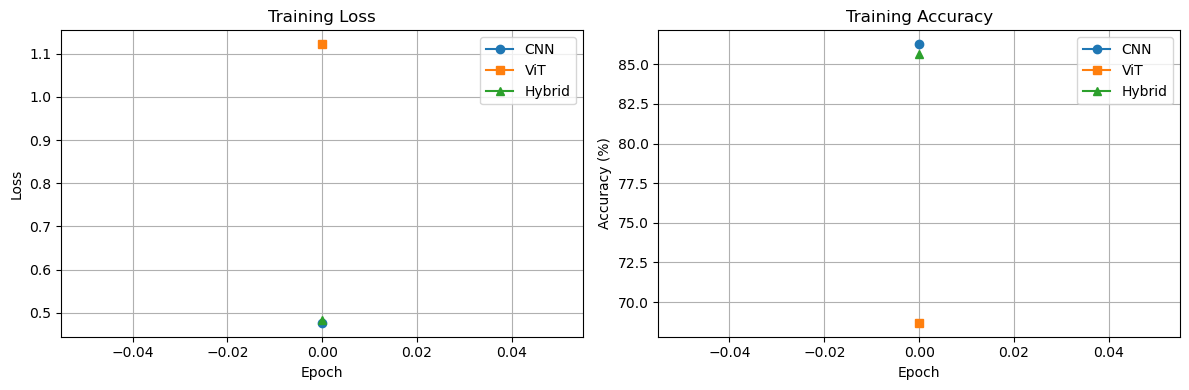


Training completed! All models saved to ../models/


In [10]:
# Plot training results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cnn_losses, label='CNN', marker='o')
ax1.plot(vit_losses, label='ViT', marker='s')
ax1.plot(hybrid_losses, label='Hybrid', marker='^')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(cnn_accs, label='CNN', marker='o')
ax2.plot(vit_accs, label='ViT', marker='s')
ax2.plot(hybrid_accs, label='Hybrid', marker='^')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../models/training_results.png')
plt.show()

print("\nTraining completed! All models saved to ../models/")
